# Telco Customer Churn - Modeling
## Introduzione
In questo notebook addestriamo e confrontiamo diversi modelli di classificazione
per predire il churn dei clienti.

## 0. Setup e Caricamento Dati


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, recall_score,precision_score,accuracy_score, f1_score
import json


In [72]:
X_train = np.load("../data/processed/X_train_scaled.npy")
X_test = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)

## 1. Baseline Model: Logistic Regression

### 1.1 Training Modello Base

In [73]:
from sklearn.linear_model import LogisticRegression

In [89]:
models = {}
model_lr  = LogisticRegression(random_state=42, class_weight="balanced")

models["Logistic Regression"] = model_lr
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:,1]

Valutazione del modello Logistic Regression:
[[747 288]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Roc-AUC score: 0.8412


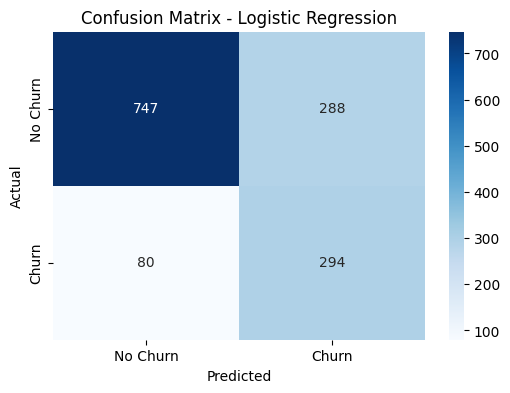

In [ ]:
print("Valutazione del modello Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(f"Roc-AUC score: {roc_auc_score(y_test,y_proba_lr):.4f}")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), 
            annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Churn", "Churn"], 
            yticklabels=["No Churn", "Churn"]) 
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [91]:
coeff = model_lr.coef_[0].flatten()
feature_importance = pd.Series(coeff, index=feature_names).sort_values(ascending=False)
print(f"Coefficienti del modello Logistic: \n {feature_importance}")

Coefficienti del modello Logistic: 
 remainder__InternetService_Fiber optic                0.700403
remainder__is_new_customer                            0.692383
remainder__StreamingMovies                            0.523334
remainder__StreamingTV                                0.494720
remainder__MultipleLines                              0.364464
remainder__PaperlessBilling                           0.343535
remainder__SeniorCitizen                              0.156152
remainder__DeviceProtection                           0.138502
remainder__tenure_group                               0.135860
remainder__PaymentMethod_Electronic check             0.069610
remainder__gender                                     0.029274
remainder__Partner                                    0.021423
remainder__OnlineBackup                               0.014353
remainder__num_services                              -0.063155
remainder__TechSupport                               -0.157563
remainder__Depende

**Nota Tecnica**
I coefficienti calcolati dal modello logistic regression rispecchiano quella che è l'influenza della feature sulla scelta della classe. I coefficienti positivi mostrano quelle feature che sono più impattanti nella scelta di andarsene, classe 1, mentre quelli negativi di restare, classe 0

## 2. Random Forest
### 2.1 Training


In [92]:
#Libreria per Random Forest
from sklearn.ensemble import RandomForestClassifier

In [106]:
#Creazione del modello
model_rf = RandomForestClassifier(
    n_estimators = 100, 
    max_depth = 10, 
    random_state = 42,
    n_jobs = -1,   
    class_weight="balanced"
    
)
#fit del modello
model_rf.fit(X_train, y_train)
models["Random Forest"] = model_rf

#Predizioni
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:,1]

print("Valutazione del modello Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(f"Roc-AUC score: {roc_auc_score(y_test,y_proba_rf):.4f}")


Valutazione del modello Random Forest:
[[809 226]
 [105 269]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

Roc-AUC score: 0.8382


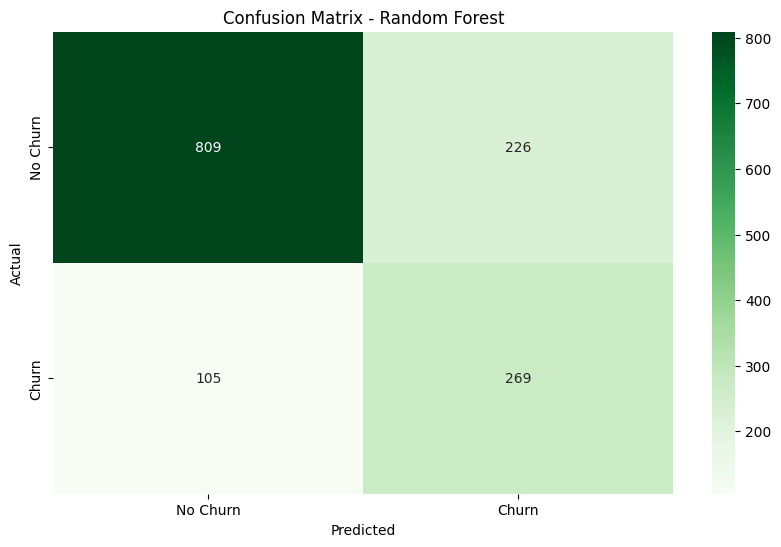

In [107]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), 
            annot=True, fmt="d", cmap="Greens", 
            xticklabels=["No Churn", "Churn"], 
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [108]:
feature_importance_rf = pd.Series(model_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print(f"Importanza delle feature - Random Forest: \n {feature_importance_rf.head(10)}")


Importanza delle feature - Random Forest: 
 remainder__Contract                          0.166212
scaler__tenure                               0.159223
scaler__MonthlyCharges                       0.114550
remainder__InternetService_Fiber optic       0.062478
remainder__tenure_group                      0.062087
remainder__OnlineSecurity                    0.042626
remainder__PaymentMethod_Electronic check    0.042535
remainder__is_new_customer                   0.040794
remainder__TechSupport                       0.031369
remainder__num_services                      0.030936
dtype: float64


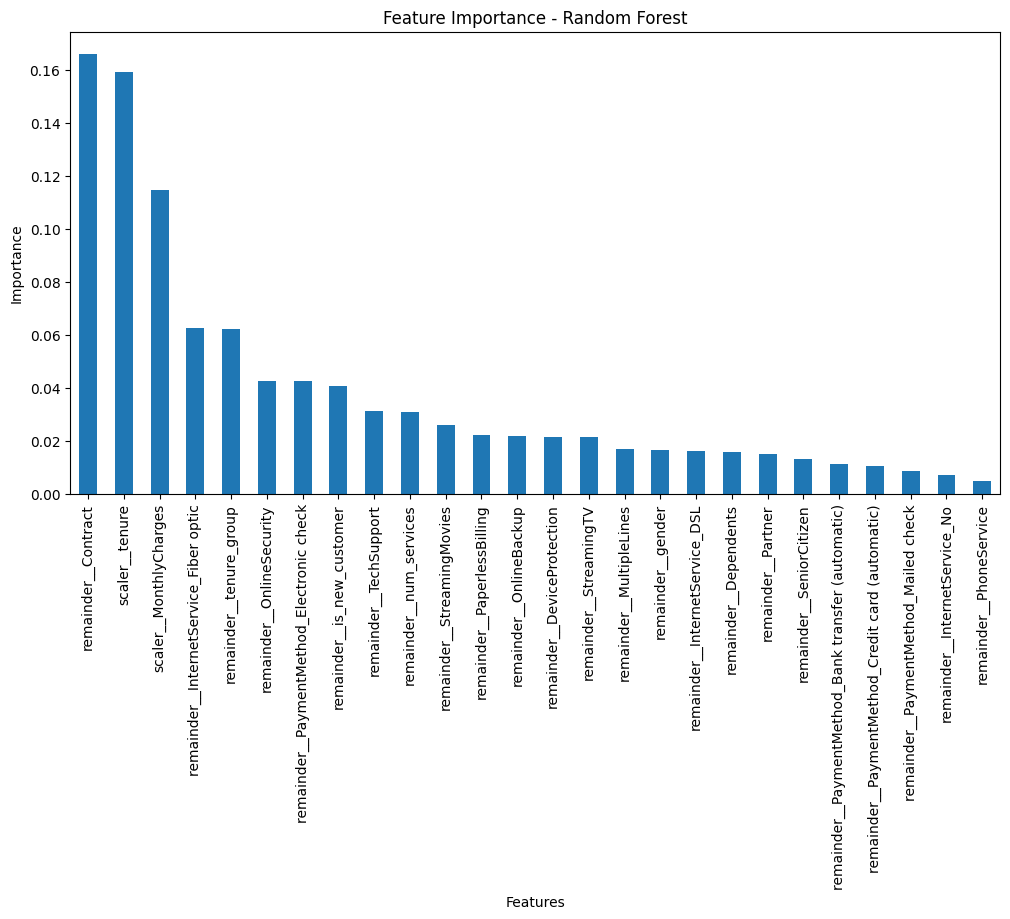

In [109]:
plt.figure(figsize=(12,6))
feature_importance_rf.plot.bar()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

## 3. Gradient Boosting

### 3.1 Training

In [110]:
#Libreria per XGBClassifier
from xgboost import XGBClassifier

In [116]:
#Creazione del modello
#help(XGBClassifier)
counts = np.bincount(y_train)
ratio = counts[0] / counts[1]

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs = -1,
    scale_pos_weight=ratio,
    subsample=0.8,
)

models["XGBoost"] = model_xgb
#addestramento del modello
model_xgb.fit(X_train, y_train)

#Predizioni
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:,1]

### 3.2 Valutazione


Valutazione del modello XGBoost:
[[787 248]
 [102 272]]
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.52      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Roc-AUC score: 0.8314


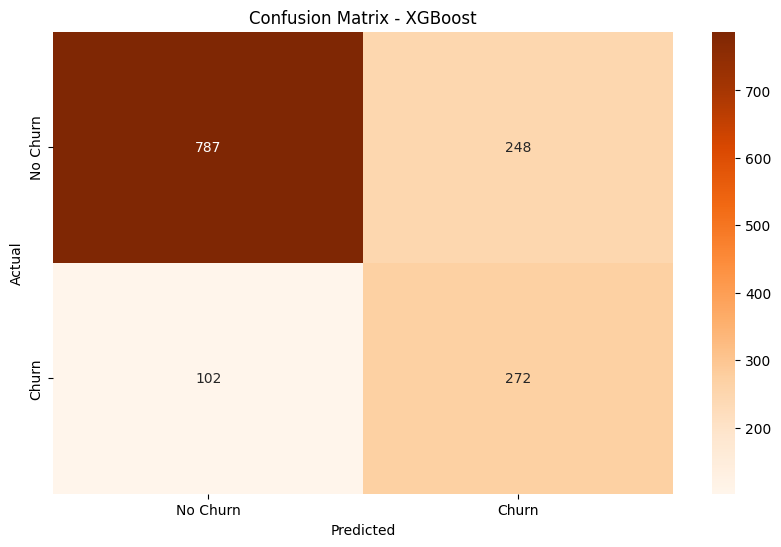

In [118]:
print("Valutazione del modello XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(f"Roc-AUC score: {roc_auc_score(y_test,y_proba_xgb):.4f}")  

plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), 
            annot=True, fmt="d", cmap="Oranges", 
            xticklabels=["No Churn", "Churn"], 
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 4. Confronto Modelli

### 4.1 Tabella Riepilogativa

In [119]:

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} - Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}, Roc-AUC: {roc_auc:.4f}, F1-Score: {f1:.4f}\n")

Logistic Regression - Precision: 0.5052, Recall: 0.7861, Accuracy: 0.7388, Roc-AUC: 0.8412, F1-Score: 0.6151

Random Forest - Precision: 0.5434, Recall: 0.7193, Accuracy: 0.7651, Roc-AUC: 0.8382, F1-Score: 0.6191

XGBoost - Precision: 0.5231, Recall: 0.7273, Accuracy: 0.7516, Roc-AUC: 0.8314, F1-Score: 0.6085



### 4.2 Visualizzazione ROC Curves


In [120]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc

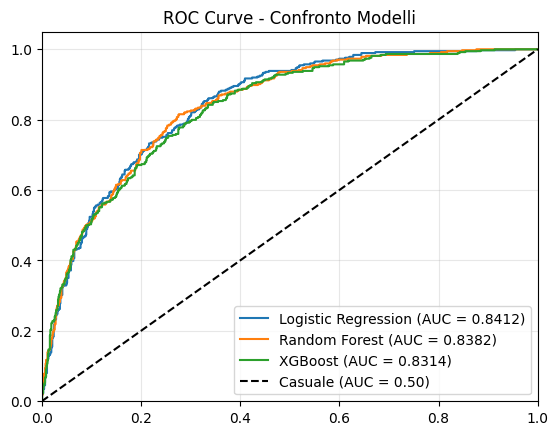

In [121]:
for nome, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr,tpr,label  = f"{nome   } (AUC = {roc_auc:.4f})")
    
plt.plot([0, 1], [0, 1], 'k--', label='Casuale (AUC = 0.50)')
plt.xlim([0.0, 1.0])    
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.title("ROC Curve - Confronto Modelli")
plt.grid(alpha=0.3)
plt.show()

## 5. Hyperparameter Tuning


### 5.1 Tuning XGB (RandomizedSearchCV)

In [126]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [129]:
param_dist_xgb = {
    'n_estimators': randint(100, 500),  # Numero di alberi
    'learning_rate': uniform(0.01, 0.19),              # Tasso di apprendimento
    'max_depth': randint(3, 10),                      # Profondità massima degli alberi
    'subsample': uniform(0.6, 0.4),           # Percentuale di dati per ogni albero
    'colsample_bytree': uniform(0.6, 0.4),    # Percentuale di feature per ogni albero
    'gamma': uniform(0, 1.0)             # Regolarizzazione (riduzione perdita minima)
}

random_search_xgb = RandomizedSearchCV(
    estimator = model_xgb,
    param_distributions = param_dist_xgb,
    n_iter = 50,
    cv = 5,
    n_jobs = -1,
    verbose  = 1,
    random_state=42,
    scoring="f1"
)

random_search_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x11b82c7a0>, 'gamma': <scipy.stats....t 0x10a6e3c50>, 'learning_rate': <scipy.stats....t 0x11c4fa350>, 'max_depth': <scipy.stats....t 0x119fb7130>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the

In [141]:
print(f"Migliori iperparametri per XGBoost:\n {random_search_xgb.best_params_}")
print(f"Miglior f1-score: {random_search_xgb.best_score_:.4f}")



Migliori iperparametri per XGBoost:
 {'colsample_bytree': np.float64(0.8439986631130484), 'gamma': np.float64(0.8331949117361643), 'learning_rate': np.float64(0.042939284166476695), 'max_depth': 3, 'n_estimators': 149, 'subsample': np.float64(0.8650089137415928)}
Miglior f1-score: 0.6368


### 5.2 RandomForest (RandomizedSearchCV)


In [191]:
param_dist_rf = {
    'n_estimators': randint(100, 500),  # Numero di alberi
    'max_depth': randint(5, 15),  # Profondità massima degli alberi
    'min_samples_split': randint(2, 10),  # Numero di campioni minimi per split
    'min_samples_leaf': randint(10,50),  # Numero di campioni minimi per foglia
    'max_features': ['sqrt', 'log2'], # Quante feature guardare per ogni split
    'bootstrap': [True],
    "class_weight": ['balanced', 'balanced_subsample']
    }

random_search_rf = RandomizedSearchCV(
    estimator = model_rf,
    param_distributions= param_dist_rf,
    cv = 5,
    scoring = "f1",
    random_state  = 42,
    n_jobs=-1,
    verbose = 1,
    n_iter = 50
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': <scipy.stats....t 0x11cf37c40>, 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [192]:


print(f"Migliori iperparametri per Random Forest:\n {random_search_rf.best_params_}")
print(f"Miglior f1-score: {random_search_rf.best_score_:.4f}")



Migliori iperparametri per Random Forest:
 {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 14, 'min_samples_split': 5, 'n_estimators': 197}
Miglior f1-score: 0.6363


### 5.3 Confronto Modelli Tunati


In [193]:
models_tuned = {
    "Random Forest Tuned": random_search_rf,
    "XGBoost Tuned": random_search_xgb,
}

results = []
    
for name, search in models_tuned.items(): 
    best_model = search.best_estimator_ 
    # Predizioni sul test set (usando la soglia standard 0.5 per ora)
    y_pred = best_model.predict(X_test)
    
    results.append({
        'Modello': name,
        'CV Score (F1)': search.best_score_,          # Media ottenuta in tuning
        'Test Score (F1)': f1_score(y_test, y_pred),  # Verifica su dati nuovi
        'Best Params': search.best_params_
    })

y_pred = model_lr.predict(X_test)
results.append({
    'Modello': "Logistic Regression Base",
    'Test Score (F1)': f1_score(y_test, y_pred),
})
# Crea un DataFrame per confrontarli facilmente
df_comparison = pd.DataFrame(results).sort_values(by='Test Score (F1)', ascending=False)
print(df_comparison[['Modello', 'CV Score (F1)', 'Test Score (F1)']])

                    Modello  CV Score (F1)  Test Score (F1)
0       Random Forest Tuned       0.636323         0.636066
1             XGBoost Tuned       0.636821         0.623053
2  Logistic Regression Base            NaN         0.615063


Random Forest Tuned risulta il modello migliore sul test set (F1 = 0.636066).
Procediamo con threshold tuning e analisi delle feature.

In [194]:
best_model  = random_search_rf.best_estimator_


## 6. Threshold Tuning

### 6.1 Precision-Recall Curve

In [195]:
from sklearn.metrics import precision_recall_curve


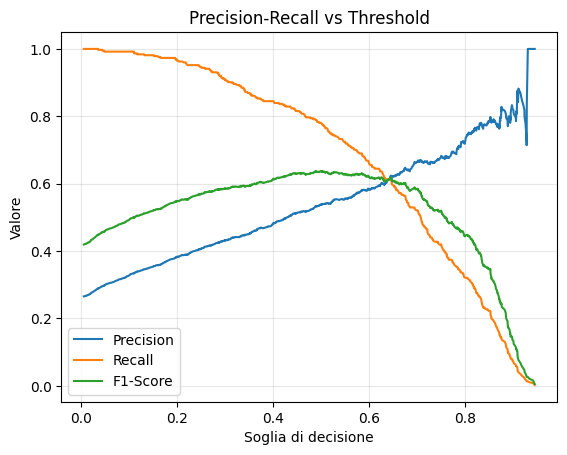

In [196]:
y_proba = best_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-Score")
plt.xlabel("Soglia di decisione")
plt.ylabel("Valore")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
recall_at_best = recall[best_idx]
precision_at_best = precision[best_idx]




### 6.2 Threshold Ottimale


In [197]:
print(f"Soglia ottimale: {best_threshold:.4f} con F1-Score: {best_f1:.4f}")
print(f"Precision: {precision_at_best:.4f}, Recall: {recall_at_best:.4f} a questa soglia")

Soglia ottimale: 0.4995 con F1-Score: 0.6376
Precision: 0.5387, Recall: 0.7807 a questa soglia


## 7. Feature Importance

### 7.1 Visualizzazione


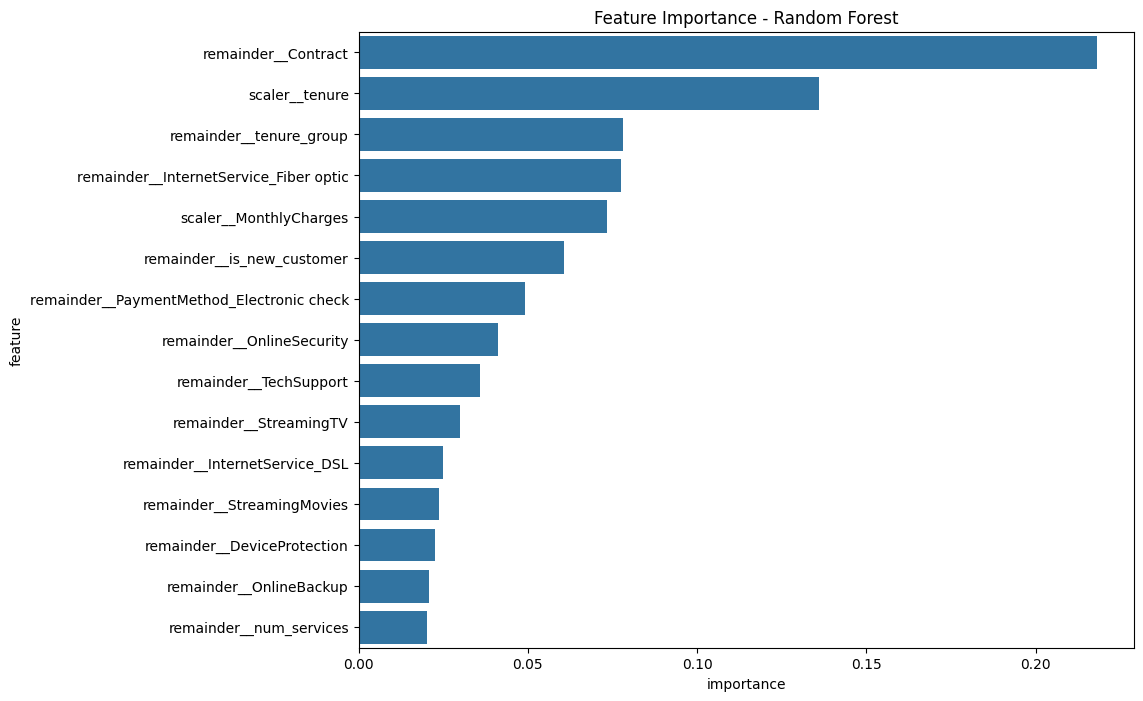

In [198]:
importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.show()

## 8. Interpretazione Business

### 8.1 Scelta del Threshold


In un contesto reale, la scelta del threshold dipenderebbe da un'analisi 
costi-benefici specifica. In assenza di questi dati, abbiamo ottimizzato 
per F1-score. Il threshold di 0.49 produce:
- Recall: circa 80% (catturiamo 4 churner su 5)
- Precision: 54% (metà delle predizioni positive sono corrette)

Questo significa che per ogni 10 clienti identificati come a rischio, 
5 lo sono effettivamente e 5 sarebbero rimasti comunque.

### 8.2 Driver del Churn

Le feature più discriminanti sono:

1. **Contract**: clienti month-to-month hanno rischio churn 10x superiore 
   rispetto a contratti biennali
   
2. **tenure**: i primi 12 mesi sono critici, dopo la retention aumenta
   
3. **MonthlyCharges**: spese elevate correlano con maggior rischio
   


## 9. Valutazione Finale

### 9.1 Performance sul Test Set

Valutazione del modello Random Forest con soglia ottimizzata: 0.4995
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409

Roc-AUC score: 0.8427


<Figure size 1000x600 with 0 Axes>

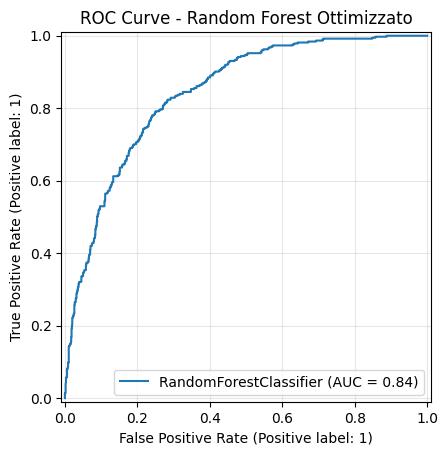

In [199]:
y_pred_final = (y_proba >= best_threshold).astype(int)
print(f"Valutazione del modello Random Forest con soglia ottimizzata: {best_threshold:.4f}")
print(classification_report(y_test, y_pred_final))
print(f"Roc-AUC score: {roc_auc_score(y_test,y_proba):.4f}")


plt.figure(figsize=(10,6))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Random Forest Ottimizzato")
plt.grid(alpha=0.3)
plt.show()

### 9.2 Confusion Matrix Finale


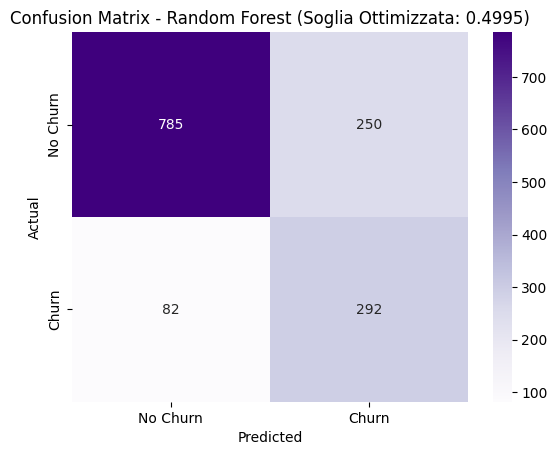

In [200]:
sns.heatmap(confusion_matrix(y_test, y_pred_final),
            annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix - Random Forest (Soglia Ottimizzata: {best_threshold:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 9.3 Conclusioni

#### Riepilogo del Progetto

Abbiamo sviluppato un modello predittivo per identificare i clienti a rischio churn seguendo un workflow completo: EDA, data quality assessment, feature engineering, confronto tra modelli (Logistic Regression, Random Forest, XGBoost), hyperparameter tuning e threshold optimization.

#### Risultati Finali

| Metrica | Valore |
|---------|--------|
| Modello | Random Forest (tunato) |
| Threshold | 0.49 |
| Precision | 54% |
| Recall | 80% |
| F1-Score | ~0.65 |
| ROC-AUC | 0.84 |

Il modello identifica correttamente 4 clienti su 5 che abbandoneranno il servizio. Su 10 interventi di retention attivati, circa 5-6 saranno su clienti realmente a rischio.

#### Profilo Cliente a Rischio

L'analisi ha identificato il cliente tipo a rischio churn: nuovo cliente (primi 12 mesi), contratto month-to-month, spese mensili elevate, senza servizi aggiuntivi come OnlineSecurity o TechSupport.

#### Raccomandazioni Operative

1. **Onboarding intensivo** nei primi 12 mesi con check-in periodici
2. **Incentivi** per passare da contratto mensile ad annuale/biennale
3. **Promozione servizi aggiuntivi** come leva di retention
4. **Alert automatici** per clienti high-value in month-to-month

#### Limiti e Sviluppi Futuri

**Limiti:** threshold ottimizzato su F1 in assenza di dati sui costi reali; dataset statico senza considerare trend temporali; mancanza di variabili come storico reclami o interazioni con customer service.

**Sviluppi possibili:** integrazione con dati di costo per ottimizzazione economica; survival analysis per stimare quando avverrà il churn; A/B testing delle strategie di retention.

